In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

sys.path.insert(0, str(Path("../../nogse_pipeline/src")))
from models.model_fitting import M_ogse_mixed_offset

In [2]:
MASTER_PATH  = Path("../../analysis/brains/ogse_experiments/master.long.parquet")
OUT_DIR      = Path("../../analysis/brains/ogse_experiments/mixed_global_fits")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS  = ["tra", "long"]
N_LIST      = [4, 8]
D0_FIXED    = 3.2e-12   # m²/ms, fixed
RN_FIXED    = 15.0       # fixed Rician noise floor
ALPHA_FIXED = 0       # None → alpha is fitted globally; float → alpha is pinned

In [3]:
df = pd.read_parquet(MASTER_PATH)

data = df[
    (df.row_kind == "signal_rotated") &
    (df.direction.isin(DIRECTIONS)) &
    (df.N.isin(N_LIST)) &
    (df.stat == "avg")
].copy()

data["G_eff"] = data.g_thorsten * data.grad_correction_factor

print(f"Rows loaded: {len(data)}")
print("Groups (subj, roi, dir):", data.groupby(["subj", "roi", "direction"]).ngroups)
data[["subj", "roi", "direction", "td_ms", "N", "G_eff", "value"]]

Rows loaded: 4532
Groups (subj, roi, dir): 48


,subj,roi,direction,td_ms,N,G_eff,value
5302,BRAIN,AntCC,tra,90.0,4,0.000000,250.168675
5303,BRAIN,AntCC,tra,90.0,4,6.213986,244.684694
5304,BRAIN,AntCC,tra,90.0,4,12.427971,228.825266
5305,BRAIN,AntCC,tra,90.0,4,18.641957,214.273122
5306,BRAIN,AntCC,tra,90.0,4,24.855943,194.742588
...,...,...,...,...,...,...,...
180571,MBBL,Syringe,long,210.0,8,35.158500,77.874817
180572,MBBL,Syringe,long,210.0,8,41.018251,26.327069
180573,MBBL,Syringe,long,210.0,8,46.878001,11.479045
180574,MBBL,Syringe,long,210.0,8,52.737751,9.976694


In [4]:
def fit_group(group_df):
    """Global fit of M_ogse_mixed_offset for one (subj, roi, dir) group."""
    tds = sorted([float(t) for t in group_df.td_ms.unique()])

    # Collect one curve per (td, N)
    curves = []
    for td in tds:
        for N in N_LIST:
            sub = group_df[
                np.isclose(group_df.td_ms.astype(float), td) & (group_df.N == N)
            ].sort_values("G_eff")
            if len(sub) == 0:
                continue
            curves.append(dict(td=td, N=int(N), G=sub.G_eff.values, y=sub.value.values))

    # Parameter layout:
    #   params[0]                  = log(tc)          [global]
    #   params[1]                  = alpha             [global, only if ALPHA_FIXED is None]
    #   params[i_base + 2*i]       = M0 for tds[i]    [per td]
    #   params[i_base + 2*i + 1]   = C  for tds[i]    [per td]
    i_base = 2 if ALPHA_FIXED is None else 1

    def residuals(params):
        tc    = np.exp(params[0])
        alpha = params[1] if ALPHA_FIXED is None else ALPHA_FIXED
        res = []
        for c in curves:
            i_td = tds.index(c["td"])
            M0 = params[i_base + 2 * i_td]
            C  = params[i_base + 2 * i_td + 1]
            x  = c["td"] / c["N"]
            with np.errstate(over="ignore", invalid="ignore"):
                y_hat = M_ogse_mixed_offset(
                    c["td"], c["G"], c["N"], x, tc, alpha, M0, D0_FIXED, C, RN_FIXED
                )
            res.append(y_hat - c["y"])
        out = np.concatenate(res)
        # Replace NaN/Inf with a large penalty so the optimizer steers away
        return np.where(np.isfinite(out), out, 1e6)

    M0_init = float(group_df.value.max())
    # tc lower bound: _rest_log_attenuation has terms exp(x/tc); x_max = 210/4 = 52.5 ms.
    # exp overflows when x/tc > ~709 → tc_min = 52.5/709 ≈ 0.074 ms; use 0.5 ms to stay safe.
    x0    = [np.log(1.0)]
    lower = [np.log(0.5)]
    upper = [np.log(500.0)]
    if ALPHA_FIXED is None:
        x0 += [0.5];    lower += [0.0];     upper += [1.0]
    for _ in tds:
        x0 += [M0_init, 0.0]
        lower += [0.0,  -np.inf]
        upper += [np.inf, np.inf]

    result = least_squares(residuals, x0, bounds=(lower, upper), method="trf", max_nfev=10000)
    return result, tds, curves, i_base

In [5]:
rows      = []
fit_store = {}   # (subj, roi, direction) → fit info for plotting

for (subj, roi, direction), grp in data.groupby(["subj", "roi", "direction"]):
    print(f"Fitting  {subj:6s}  {roi:25s}  {direction} ...", end="  ")
    result, tds, curves, i_base = fit_group(grp)
    params = result.x
    tc     = float(np.exp(params[0]))
    alpha  = float(params[1]) if ALPHA_FIXED is None else float(ALPHA_FIXED)
    print(f"tc = {tc:.3f} ms   alpha = {alpha:.3f}   cost = {result.cost:.3e}")

    fit_store[(subj, roi, direction)] = dict(
        tds=tds, curves=curves, params=params, tc=tc, alpha=alpha, i_base=i_base
    )

    for c in curves:
        i_td = tds.index(c["td"])
        M0 = float(params[i_base + 2 * i_td])
        C  = float(params[i_base + 2 * i_td + 1])
        rows.append(dict(
            subj=subj, roi=roi, direction=direction,
            td_ms=c["td"],  N=c["N"],
            tc_ms=tc,        alpha=alpha,  D0_m2ms=D0_FIXED,
            M0=M0,           C=C,          RN=RN_FIXED,
            cost=float(result.cost),  success=bool(result.success),
        ))

Fitting  BRAIN   AntCC                      long ...  

tc = 19.680 ms   alpha = 0.000   cost = 4.964e+03
Fitting  BRAIN   AntCC                      tra ...  tc = 17.605 ms   alpha = 0.000   cost = 4.351e+03
Fitting  BRAIN   CentralCC                  long ...  tc = 20.574 ms   alpha = 0.000   cost = 9.684e+03
Fitting  BRAIN   CentralCC                  tra ...  tc = 41.914 ms   alpha = 0.000   cost = 5.309e+03
Fitting  BRAIN   Left-Lateral-Ventricle     long ...  tc = 193.947 ms   alpha = 0.000   cost = 8.429e+03
Fitting  BRAIN   Left-Lateral-Ventricle     tra ...  tc = 484.851 ms   alpha = 0.000   cost = 7.526e+03
Fitting  BRAIN   MidAntCC                   long ...  tc = 22.119 ms   alpha = 0.000   cost = 4.635e+03
Fitting  BRAIN   MidAntCC                   tra ...  tc = 19.627 ms   alpha = 0.000   cost = 4.139e+03
Fitting  BRAIN   MidPostCC                  long ...  tc = 64.106 ms   alpha = 0.000   cost = 1.191e+04
Fitting  BRAIN   MidPostCC                  tra ...  tc = 42.884 ms   alpha = 0.000   cost = 1.039e+04
Fitting  BRAIN   

In [6]:
results_df = pd.DataFrame(rows)
results_df.to_excel(OUT_DIR / "fit_results.xlsx", index=False)
print(f"Saved {len(results_df)} rows to {OUT_DIR / 'fit_results.xlsx'}")
results_df

Saved 412 rows to ../../analysis/brains/ogse_experiments/mixed_global_fits/fit_results.xlsx


,subj,roi,direction,td_ms,N,tc_ms,alpha,D0_m2ms,M0,C,RN,cost,success
0,BRAIN,AntCC,long,76.0,4,19.679868,0.0,3.200000e-12,207.090299,64.693680,15.0,4964.027497,True
1,BRAIN,AntCC,long,76.0,8,19.679868,0.0,3.200000e-12,207.090299,64.693680,15.0,4964.027497,True
2,BRAIN,AntCC,long,90.0,4,19.679868,0.0,3.200000e-12,210.639381,41.757315,15.0,4964.027497,True
3,BRAIN,AntCC,long,90.0,8,19.679868,0.0,3.200000e-12,210.639381,41.757315,15.0,4964.027497,True
4,BRAIN,AntCC,long,120.0,4,19.679868,0.0,3.200000e-12,150.200104,37.021595,15.0,4964.027497,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,MBBL,Syringe,tra,120.0,8,39.180601,0.0,3.200000e-12,1895.363085,18.316471,15.0,32520.572437,True
408,MBBL,Syringe,tra,143.4,4,39.180601,0.0,3.200000e-12,2135.332677,42.415947,15.0,32520.572437,True
409,MBBL,Syringe,tra,143.4,8,39.180601,0.0,3.200000e-12,2135.332677,42.415947,15.0,32520.572437,True
410,MBBL,Syringe,tra,210.0,4,39.180601,0.0,3.200000e-12,1823.738648,-10.468278,15.0,32520.572437,True


In [7]:
G_plot = np.linspace(0, float(data.G_eff.max()), 300)

for (subj, roi, direction), store in fit_store.items():
    tds    = store["tds"]
    params = store["params"]
    i_base = store["i_base"]
    n_tds  = len(tds)

    fig, axes = plt.subplots(1, n_tds, figsize=(4 * n_tds, 3.5), sharey=True)
    axes = np.atleast_1d(axes)

    for i_td, (ax, td) in enumerate(zip(axes, tds)):
        M0 = params[i_base + 2 * i_td]
        C  = params[i_base + 2 * i_td + 1]
        for N, color in zip(N_LIST, ["C0", "C1"]):
            c = next((x for x in store["curves"] if x["td"] == td and x["N"] == N), None)
            if c is None:
                continue
            ax.scatter(c["G"], c["y"], color=color, s=20, zorder=3, label=f"N={N} data")
            y_hat = M_ogse_mixed_offset(
                td, G_plot, N, td / N, store["tc"], store["alpha"], M0, D0_FIXED, C, RN_FIXED
            )
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit")
        ax.set_title(f"td = {td:.1f} ms")
        ax.set_xlabel("G_eff [mT/m]")

    axes[0].set_ylabel("value [a.u.]")
    axes[0].legend(fontsize=6)
    fig.suptitle(
        f"{subj}  |  {roi}  |  {direction}  |  "
        f"tc = {store['tc']:.2f} ms   α = {store['alpha']:.3f}",
        fontsize=9
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Fit plots (with M0) saved.")

Fit plots (with M0) saved.


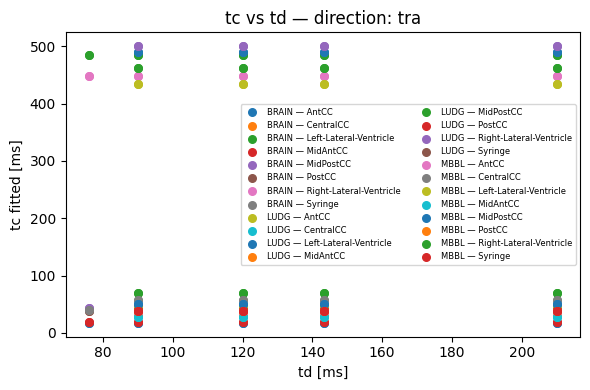

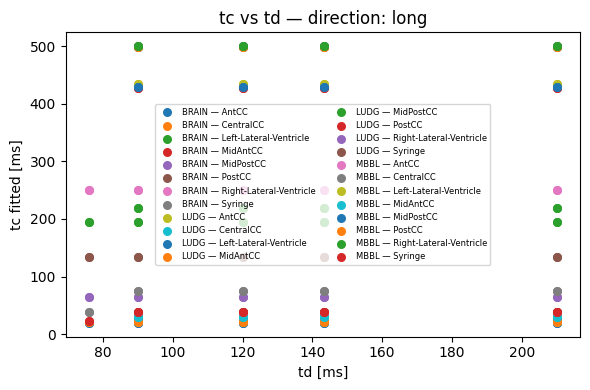

In [8]:
for direction in DIRECTIONS:
    sub = results_df[results_df.direction == direction]
    fig, ax = plt.subplots(figsize=(6, 4))
    for (subj, roi), g in sub.groupby(["subj", "roi"]):
        ax.scatter(g.td_ms, g.tc_ms, s=30, label=f"{subj} — {roi}")
    ax.set_xlabel("td [ms]")
    ax.set_ylabel("tc fitted [ms]")
    ax.set_title(f"tc vs td — direction: {direction}")
    ax.legend(fontsize=6, ncol=2)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"tc_vs_td_{direction}.png", dpi=120)
    plt.show()

In [9]:
for (subj, roi, direction), store in fit_store.items():
    tds    = store["tds"]
    params = store["params"]
    i_base = store["i_base"]
    n_tds  = len(tds)

    fig, axes = plt.subplots(1, n_tds, figsize=(4 * n_tds, 3.5), sharey=True)
    axes = np.atleast_1d(axes)

    for i_td, (ax, td) in enumerate(zip(axes, tds)):
        M0 = params[i_base + 2 * i_td]
        C  = params[i_base + 2 * i_td + 1]
        for N, color in zip(N_LIST, ["C0", "C1"]):
            c = next((x for x in store["curves"] if x["td"] == td and x["N"] == N), None)
            if c is None:
                continue
            # data and model both divided by M0 (M0=1 in the model)
            ax.scatter(c["G"], c["y"] / M0, color=color, s=20, zorder=3, label=f"N={N} data")
            y_hat = M_ogse_mixed_offset(
                td, G_plot, N, td / N,
                store["tc"], store["alpha"], 1.0, D0_FIXED, C / M0, RN_FIXED / M0
            )
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit (M0=1)")
        ax.set_title(f"td = {td:.1f} ms")
        ax.set_xlabel("G_eff [mT/m]")

    axes[0].set_ylabel("value / M0  [a.u.]")
    axes[0].legend(fontsize=6)
    fig.suptitle(
        f"{subj}  |  {roi}  |  {direction}  |  normalised (M0 = 1)",
        fontsize=9
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_norm_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Normalised fit plots saved.")

Normalised fit plots saved.
